--- ОТЧЕТ ПО КАТЕГОРИЯМ ДОХОДНОСТИ ---
                   precision    recall  f1-score   support

          0. Loss       0.17      0.26      0.21        27
    1. Low (0-5%)       0.20      0.24      0.22        66
   2. Mid (5-10%)       0.28      0.31      0.29       122
 3. High (10-20%)       0.37      0.30      0.33       138
4. Extreme (>20%)       0.33      0.05      0.08        21

         accuracy                           0.28       374
        macro avg       0.27      0.23      0.23       374
     weighted avg       0.29      0.28      0.28       374



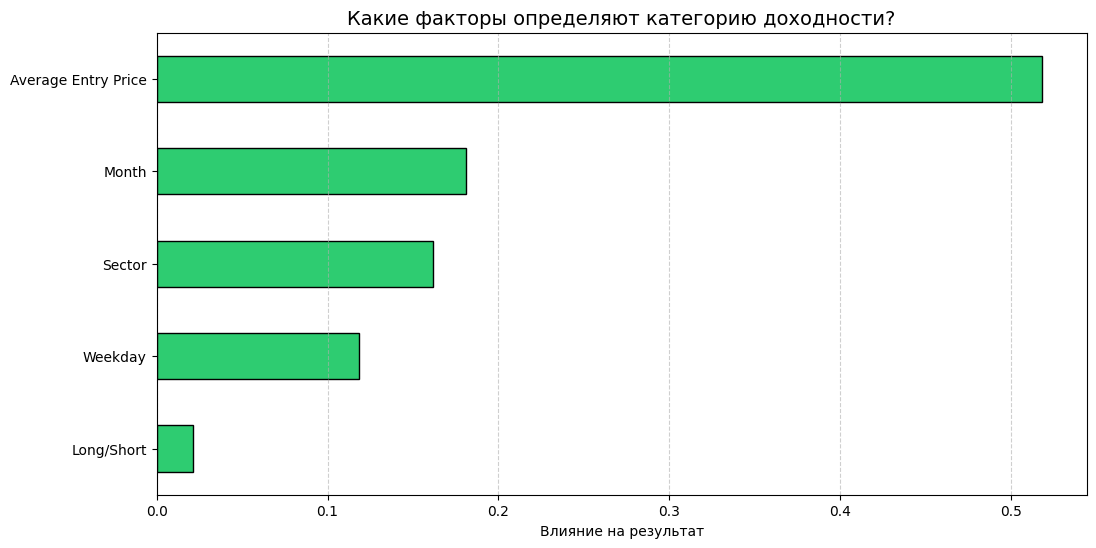

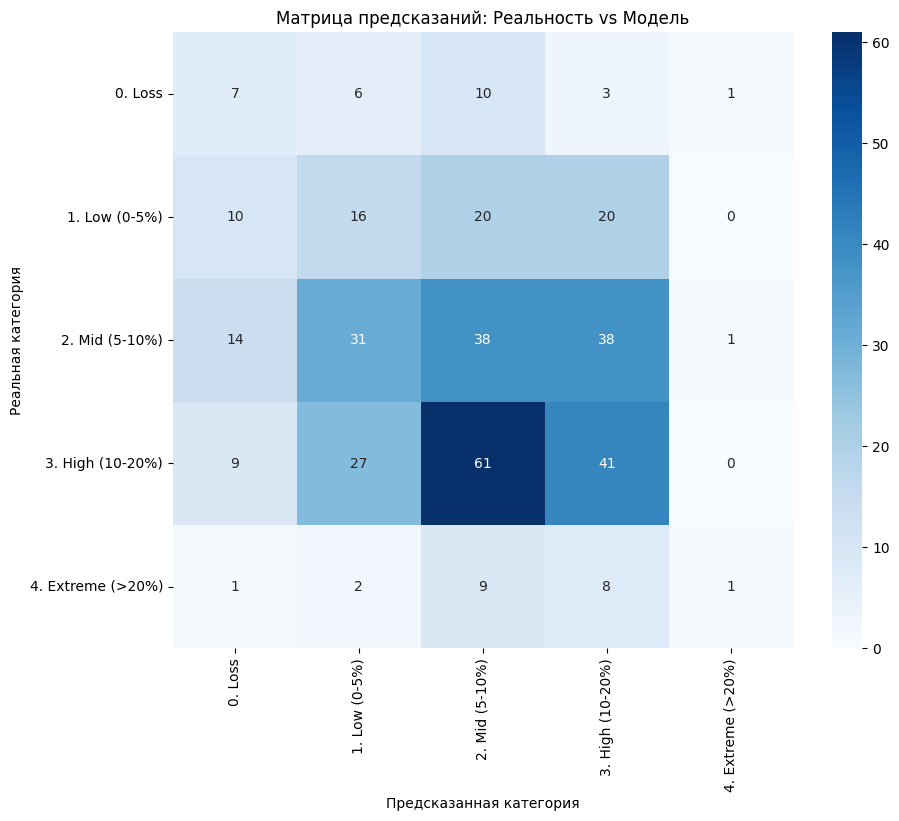

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# 1. ЗАГРУЗКА И ПОДГОТОВКА КАТЕГОРИЙ
df = pd.read_csv(r'C:\Users\USER\Desktop\Folder\Murat\DS\Outpeer\Capstone\NewTry\trades_structured2.csv')

def categorize_profit(p):
    if p <= 0: return '0. Loss'
    if p <= 5: return '1. Low (0-5%)'
    if p <= 10: return '2. Mid (5-10%)'
    if p <= 20: return '3. High (10-20%)'
    return '4. Extreme (>20%)'

df['Profit_Class'] = df['Profit %'].apply(categorize_profit)

# 2. ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ
features = ['Sector', 'Long/Short', 'Average Entry Price', 'Month', 'Weekday']
X = df[features].copy()
y = df['Profit_Class']

# Кодируем текст в числа
le_dict = {}
for col in ['Sector', 'Long/Short', 'Weekday']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

# 3. ТЕМПОРАЛЬНОЕ РАЗБИЕНИЕ (Train/Test)
# Обучаем на данных до 2024 года, тестируем на 2024-2026
train_mask = df['Year'] < 2024
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

# 4. ОБУЧЕНИЕ МОДЕЛИ (Multiclass Classification)
model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# 5. ОЦЕНКА И ВЫВОД РЕЗУЛЬТАТОВ
y_pred = model.predict(X_test)

print("--- ОТЧЕТ ПО КАТЕГОРИЯМ ДОХОДНОСТИ ---")
print(classification_report(y_test, y_pred))

# 6. ВИЗУАЛИЗАЦИЯ 1: ВАЖНОСТЬ ПРИЗНАКОВ
plt.figure(figsize=(12, 6))
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
importances.plot(kind='barh', color='#2ecc71', edgecolor='black')
plt.title('Какие факторы определяют категорию доходности?', fontsize=14)
plt.xlabel('Влияние на результат')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# 7. ВИЗУАЛИЗАЦИЯ 2: МАТРИЦА ОШИБОК
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, 
            yticklabels=model.classes_)
plt.title('Матрица предсказаний: Реальность vs Модель')
plt.ylabel('Реальная категория')
plt.xlabel('Предсказанная категория')
plt.show()

--- СРАВНИТЕЛЬНЫЙ АНАЛИЗ АЛГОРИТМОВ ---
               Accuracy  Precision  Recall  F1-Score
Model                                               
Decision Tree     0.283      0.288   0.283     0.270
Random Forest     0.289      0.312   0.289     0.290
XGBoost           0.299      0.309   0.299     0.299


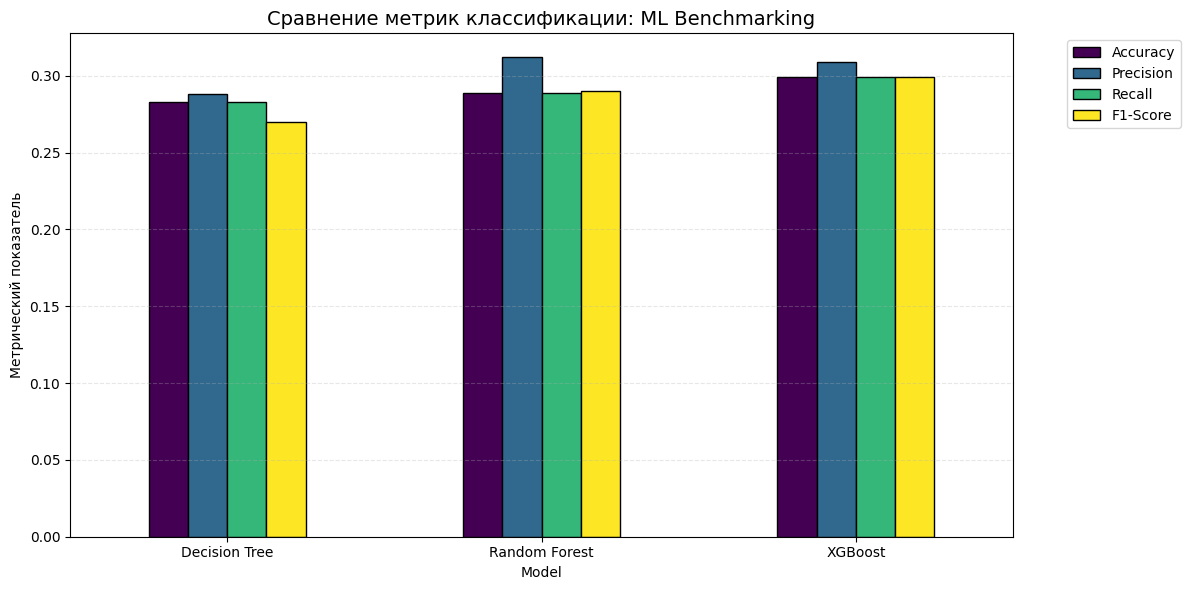

In [6]:
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score

# 1. Подготовка данных (используем те же X_train, X_test, y_train, y_test из прошлого шага)
# Для XGBoost нужно перекодировать классы в числа от 0 до N
target_le = LabelEncoder()
y_train_encoded = target_le.fit_transform(y_train)
y_test_encoded = target_le.transform(y_test)

# 2. Инициализация моделей
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

# Собираем расширенные результаты
comparison_results = []

for name, model in models.items():
    model.fit(X_train, y_train_encoded)
    y_pred = model.predict(X_test)
    
    # Считаем метрики с усреднением 'weighted', так как у нас дисбаланс классов
    acc = accuracy_score(y_test_encoded, y_pred)
    prec = precision_score(y_test_encoded, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test_encoded, y_pred, average='weighted')
    f1 = f1_score(y_test_encoded, y_pred, average='weighted')
    
    comparison_results.append({
        "Model": name, 
        "Accuracy": acc, 
        "Precision": prec, 
        "Recall": rec, 
        "F1-Score": f1
    })

# Итоговая таблица
df_compare = pd.DataFrame(comparison_results).set_index("Model").round(3)
print("--- СРАВНИТЕЛЬНЫЙ АНАЛИЗ АЛГОРИТМОВ ---")
print(df_compare)

# Визуализация для отчета
df_compare.plot(kind='bar', figsize=(12, 6), colormap='viridis', edgecolor='black')
plt.title('Сравнение метрик классификации: ML Benchmarking', fontsize=14)
plt.ylabel('Метрический показатель')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 1. Подготовка данных
# Выбираем только те сектора, где достаточно сделок для анализа (например, больше 10)
sector_counts = df['Sector'].value_counts()
top_sectors = sector_counts[sector_counts > 10].index
df_filtered = df[df['Sector'].isin(top_sectors)]

# 2. Проведение ANOVA
# Гипотеза: Средний 'Profit %' одинаков для всех секторов
model = ols('Q("Profit %") ~ Sector', data=df_filtered).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("--- ТАБЛИЦА ANOVA ---")
print(anova_table)

# 3. Интерпретация P-value
p_value = anova_table.loc['Sector', 'PR(>F)']
print(f"\nP-value: {p_value:.5f}")

if p_value < 0.05:
    print("Результат: Различия МЕЖДУ секторами СТАТИСТИЧЕСКИ ЗНАЧИМЫ.")
    print("Это значит, что выбор сектора РЕАЛЬНО влияет на доходность.")
else:
    print("Результат: Различия статистически НЕ значимы (могут быть случайны).")

--- ТАБЛИЦА ANOVA ---
                 sum_sq      df         F    PR(>F)
Sector      7737.094463    16.0  3.100873  0.000031
Residual  335439.633194  2151.0       NaN       NaN

P-value: 0.00003
Результат: Различия МЕЖДУ секторами СТАТИСТИЧЕСКИ ЗНАЧИМЫ.
Это значит, что выбор сектора РЕАЛЬНО влияет на доходность.


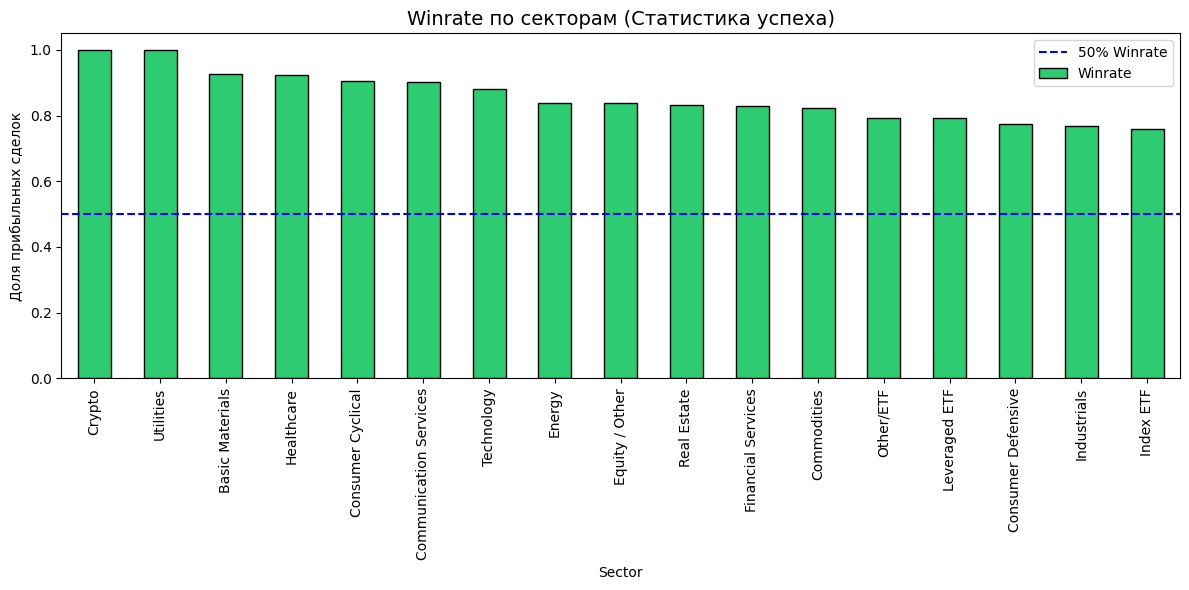

In [9]:
# Расчет винрейта по секторам
df['Is_Win'] = (df['Profit %'] > 0).astype(int)
winrate_analysis = df.groupby('Sector').agg({
    'Is_Win': 'mean',
    'Profit %': 'count'
}).rename(columns={'Is_Win': 'Winrate', 'Profit %': 'Trade_Count'})

# Фильтруем сектора, где мало сделок
winrate_analysis = winrate_analysis[winrate_analysis['Trade_Count'] > 10].sort_values('Winrate', ascending=False)

# Визуализация
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
colors = ['#2ecc71' if x > 0.5 else '#e74c3c' for x in winrate_analysis['Winrate']]
winrate_analysis['Winrate'].plot(kind='bar', color=colors, edgecolor='black')
plt.axhline(y=0.5, color='blue', linestyle='--', label='50% Winrate')
plt.title('Winrate по секторам (Статистика успеха)', fontsize=14)
plt.ylabel('Доля прибыльных сделок')
plt.legend()
plt.tight_layout()
plt.show()